# SPX Option Strategy Backtesting with optopsy

Backtests SPX option strategies over the full OptionsDX EOD history (2010–2023, ~31M contract rows).

**Before running:** make sure the raw files have been converted — `python src/convert_optionsdx.py --symbol SPX --raw-dir "spx option"` (and `--raw-dir spx_eod_2023` for 2023). Each monthly file becomes a parquet in `data/processed/`.

**Kernel:** select **Python (optopsy-spx)** (registered from this project's `.venv`), or launch Jupyter from the venv: `.venv\Scripts\Activate.ps1` then `jupyter notebook spx_backtest.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import optopsy as op
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)
print("optopsy", op.__version__)

optopsy 2.2.0


## 1. Load the processed option chains

In [2]:
files = sorted(Path("data/processed").glob("*.parquet"))
data = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)
print(f"{len(data):,} contract rows from {len(files)} files, "
      f"{data['quote_date'].min():%Y-%m-%d} to {data['quote_date'].max():%Y-%m-%d}")
data.head()

31,090,481 contract rows from 168 files, 2010-01-04 to 2023-12-29


,underlying_symbol,underlying_price,option_type,expiration,quote_date,strike,bid,ask,delta,volume
0,SPX,1132.99,c,2010-01-07,2010-01-04,925.0,205.99,208.99,1.0,NaN
1,SPX,1132.99,c,2010-01-07,2010-01-04,950.0,181.00,184.00,1.0,NaN
2,SPX,1132.99,c,2010-01-07,2010-01-04,975.0,156.00,159.00,1.0,NaN
3,SPX,1132.99,c,2010-01-07,2010-01-04,1000.0,131.10,134.10,1.0,NaN
4,SPX,1132.99,c,2010-01-07,2010-01-04,1025.0,106.21,109.20,1.0,NaN


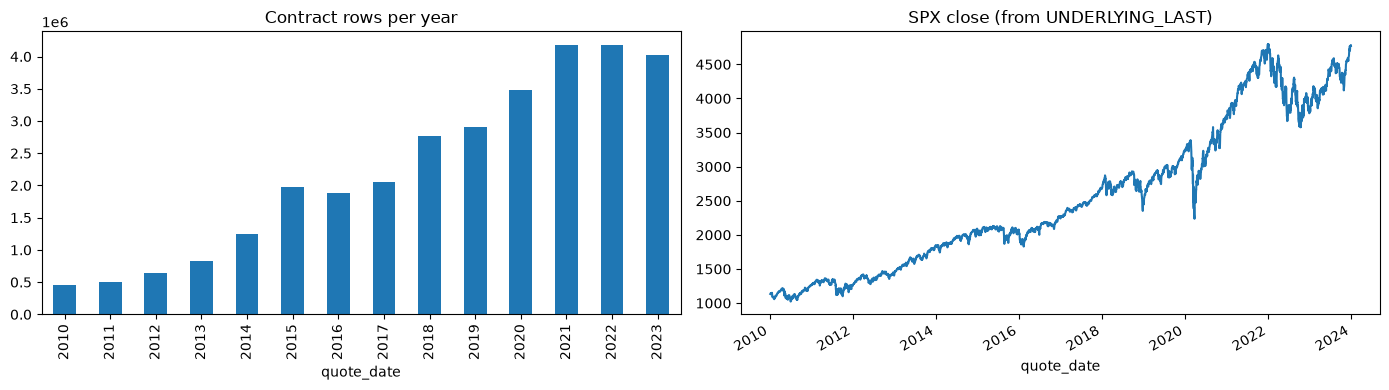

In [3]:
# Contracts per year and the SPX price path (sanity check)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
data.groupby(data["quote_date"].dt.year).size().plot.bar(ax=axes[0], title="Contract rows per year")
spx = data.groupby("quote_date")["underlying_price"].first()
spx.plot(ax=axes[1], title="SPX close (from UNDERLYING_LAST)")
plt.tight_layout()

## 2. Single-leg studies

optopsy groups every possible entry into DTE × delta buckets and reports the distribution of returns per bucket (`mean`, `win_rate`, `profit_factor`, ...). Entries are held to expiration by default (`exit_dte=0`).

In [4]:
long_calls = op.long_calls(data, max_entry_dte=60, dte_interval=7)
long_calls.sort_values("profit_factor", ascending=False).head(10)

,dte_range,delta_range,count,mean,std,min,25%,50%,75%,max,win_rate,profit_factor
23,"(35, 42]","(0.35, 0.4]",11.0,2.009060,2.134453,-0.999339,0.972080,1.458450,3.767158,5.553830,0.818182,12.060550
20,"(35, 42]","(0.2, 0.25]",14.0,2.533859,3.448609,-0.999250,-0.818940,1.636830,5.639800,8.238806,0.642857,8.842650
24,"(42, 49]","(0.2, 0.25]",6.0,1.018728,4.941324,-0.999307,-0.999247,-0.998405,-0.997464,11.105163,0.166667,2.224238
17,"(28, 35]","(0.25, 0.3]",2737.0,0.479795,2.183166,-0.999567,-0.998481,-0.968410,1.598174,16.258621,0.394593,1.865824
18,"(28, 35]","(0.3, 0.35]",2749.0,0.441918,2.004914,-0.999669,-0.998572,-0.838606,1.574586,14.923843,0.409967,1.825085
22,"(35, 42]","(0.3, 0.35]",1748.0,0.411986,2.040198,-0.999615,-0.998638,-0.948865,1.469266,10.958848,0.389588,1.741248
21,"(35, 42]","(0.25, 0.3]",1757.0,0.394527,2.041172,-0.999683,-0.998521,-0.973418,1.463806,13.391848,0.384178,1.702964
12,"(21, 28]","(0.2, 0.25]",15.0,0.462427,2.479433,-0.999336,-0.998941,-0.998339,1.296977,6.782609,0.333333,1.694621
13,"(21, 28]","(0.25, 0.3]",3608.0,0.382932,2.110382,-0.999648,-0.998762,-0.995577,1.369808,16.927152,0.382761,1.667820
14,"(21, 28]","(0.3, 0.35]",3682.0,0.336628,1.997014,-0.999651,-0.998773,-0.984863,1.368409,16.857471,0.379957,1.594824


In [5]:
short_puts = op.short_puts(data, max_entry_dte=60, dte_interval=7)
short_puts.sort_values("profit_factor", ascending=False).head(10)

,dte_range,delta_range,count,mean,std,min,25%,50%,75%,max,win_rate,profit_factor
12,"(21, 28]","(-0.4, -0.35]",3.0,0.998226,0.000355,0.997854,0.998059,0.998263,0.998412,0.998562,1.0,inf
11,"(14, 21]","(-0.25, -0.2]",1.0,0.997817,NaN,0.997817,0.997817,0.997817,0.997817,0.997817,1.0,inf
7,"(7, 14]","(-0.25, -0.2]",1.0,0.994382,NaN,0.994382,0.994382,0.994382,0.994382,0.994382,1.0,inf
19,"(28, 35]","(-0.25, -0.2]",1.0,0.997661,NaN,0.997661,0.997661,0.997661,0.997661,0.997661,1.0,inf
20,"(35, 42]","(-0.4, -0.35]",1.0,0.998696,NaN,0.998696,0.998696,0.998696,0.998696,0.998696,1.0,inf
16,"(28, 35]","(-0.4, -0.35]",1.0,0.632734,NaN,0.632734,0.632734,0.632734,0.632734,0.632734,1.0,inf
15,"(21, 28]","(-0.25, -0.2]",3.0,0.997137,0.000402,0.996691,0.996967,0.997243,0.997359,0.997475,1.0,inf
23,"(35, 42]","(-0.25, -0.2]",3.0,0.997608,0.000285,0.997313,0.997472,0.997630,0.997756,0.997881,1.0,inf
24,"(42, 49]","(-0.4, -0.35]",2.0,0.998982,0.000009,0.998975,0.998978,0.998982,0.998985,0.998988,1.0,inf
30,"(49, 56]","(-0.25, -0.2]",1.0,0.998489,NaN,0.998489,0.998489,0.998489,0.998489,0.998489,1.0,inf


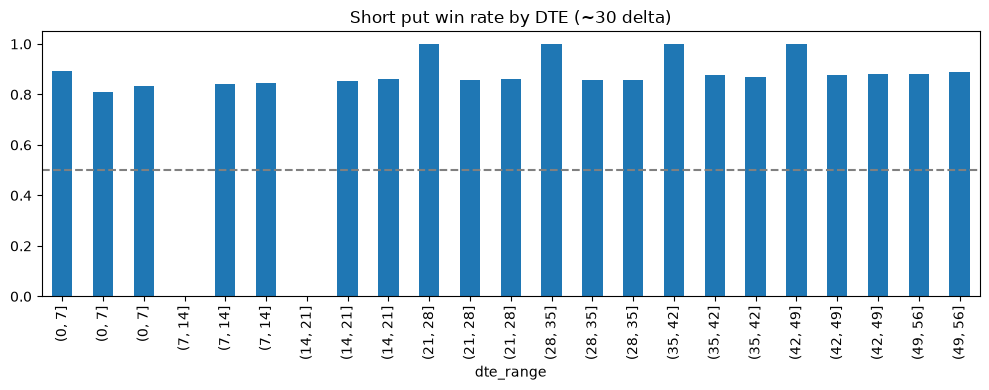

In [6]:
# Win rate by DTE bucket for ~30-delta short puts
mask = short_puts["delta_range"].astype(str).str.contains("-0.3")
short_puts[mask].plot.bar(x="dte_range", y="win_rate", figsize=(10, 4),
                          title="Short put win rate by DTE (~30 delta)", legend=False)
plt.axhline(0.5, color="grey", ls="--")
plt.tight_layout()

## 3. Iron condor

Per-leg delta targeting: legs are put wing / short put / short call / call wing. Keep the min–max bands generous — tight bands silently match zero trades.

In [7]:
condors = op.iron_condor(
    data,
    max_entry_dte=50,
    leg1_delta={"min": 0.03, "target": 0.10, "max": 0.20},  # long put wing
    leg2_delta={"min": 0.10, "target": 0.16, "max": 0.30},  # short put
    leg3_delta={"min": 0.10, "target": 0.16, "max": 0.30},  # short call
    leg4_delta={"min": 0.03, "target": 0.10, "max": 0.20},  # long call wing
)
condors.sort_values("count", ascending=False).head(15)

,dte_range,delta_range_leg1,delta_range_leg2,delta_range_leg3,delta_range_leg4,count,mean,std,min,25%,50%,75%,max,win_rate,profit_factor
51,"(7, 14]","(-0.1, -0.05]","(-0.2, -0.15]","(0.15, 0.2]","(0.05, 0.1]",1769.0,-0.059036,1.801276,-9.369863,-0.980226,0.998864,1.0,6.290909,0.696439,0.918906
76,"(14, 21]","(-0.1, -0.05]","(-0.2, -0.15]","(0.15, 0.2]","(0.05, 0.1]",1678.0,0.042301,1.774663,-10.488834,-0.438359,0.999406,1.0,1.911215,0.727652,1.064398
101,"(21, 28]","(-0.1, -0.05]","(-0.2, -0.15]","(0.15, 0.2]","(0.05, 0.1]",1675.0,0.021363,1.790606,-9.688641,-0.585094,0.999347,1.0,2.526316,0.720000,1.032052
41,"(7, 14]","(-0.15, -0.1]","(-0.2, -0.15]","(0.15, 0.2]","(0.05, 0.1]",1663.0,0.000359,1.788370,-10.081169,-0.588698,0.999219,1.0,1.845501,0.723993,1.000516
63,"(14, 21]","(-0.15, -0.1]","(-0.2, -0.15]","(0.15, 0.2]","(0.05, 0.1]",1660.0,0.020355,1.789565,-8.839950,-0.456099,0.999397,1.0,3.332555,0.726506,1.029947
77,"(14, 21]","(-0.1, -0.05]","(-0.2, -0.15]","(0.15, 0.2]","(0.1, 0.15]",1657.0,-0.063074,1.913143,-9.619785,-1.025185,0.999009,1.0,3.623025,0.702474,0.915007
88,"(21, 28]","(-0.15, -0.1]","(-0.2, -0.15]","(0.15, 0.2]","(0.05, 0.1]",1629.0,-0.141530,1.858821,-9.538902,-1.300697,0.998954,1.0,1.567430,0.673419,0.819087
64,"(14, 21]","(-0.15, -0.1]","(-0.2, -0.15]","(0.15, 0.2]","(0.1, 0.15]",1606.0,-0.056312,1.869816,-10.540041,-1.110894,0.999089,1.0,2.648529,0.701743,0.922890
42,"(7, 14]","(-0.15, -0.1]","(-0.2, -0.15]","(0.15, 0.2]","(0.1, 0.15]",1575.0,0.006641,1.849834,-9.073379,-0.716094,0.999465,1.0,15.949653,0.720000,1.009575
52,"(7, 14]","(-0.1, -0.05]","(-0.2, -0.15]","(0.15, 0.2]","(0.1, 0.15]",1562.0,0.057825,1.694904,-10.507317,-0.614588,0.999125,1.0,3.911765,0.720230,1.091565


## 4. Exits: profit target / stop loss / time stop

`take_profit` / `stop_loss` are fractions of entry credit or debit; `max_hold_days` forces a time exit.

In [8]:
managed = op.short_puts(
    data,
    max_entry_dte=60,
    dte_interval=7,
    take_profit=0.5,     # close at 50% of max profit
    stop_loss=-2.0,      # close at 2x credit loss
)
managed.sort_values("profit_factor", ascending=False).head(10)

,dte_range,delta_range,count,mean,std,min,25%,50%,75%,max,win_rate,profit_factor
12,"(21, 28]","(-0.4, -0.35]",3.0,0.675529,0.123489,0.565264,0.608812,0.652361,0.730661,0.808961,1.000000,inf
11,"(14, 21]","(-0.25, -0.2]",1.0,0.694323,NaN,0.694323,0.694323,0.694323,0.694323,0.694323,1.000000,inf
7,"(7, 14]","(-0.25, -0.2]",1.0,0.747191,NaN,0.747191,0.747191,0.747191,0.747191,0.747191,1.000000,inf
23,"(35, 42]","(-0.25, -0.2]",3.0,0.534592,0.026215,0.507109,0.522227,0.537346,0.548334,0.559322,1.000000,inf
24,"(42, 49]","(-0.4, -0.35]",2.0,0.519282,0.004085,0.516393,0.517838,0.519282,0.520726,0.522170,1.000000,inf
19,"(28, 35]","(-0.25, -0.2]",1.0,0.567251,NaN,0.567251,0.567251,0.567251,0.567251,0.567251,1.000000,inf
15,"(21, 28]","(-0.25, -0.2]",3.0,0.519422,0.005063,0.516129,0.516507,0.516885,0.521069,0.525253,1.000000,inf
30,"(49, 56]","(-0.25, -0.2]",1.0,0.501511,NaN,0.501511,0.501511,0.501511,0.501511,0.501511,1.000000,inf
27,"(42, 49]","(-0.25, -0.2]",1.0,0.553959,NaN,0.553959,0.553959,0.553959,0.553959,0.553959,1.000000,inf
29,"(49, 56]","(-0.3, -0.25]",1405.0,0.238293,0.994734,-5.498687,0.515949,0.546125,0.586916,0.875887,0.897509,1.880952


## 5. Trade-level detail

`raw=True` returns individual trades instead of bucketed stats — useful for equity curves and inspecting the tails.

In [9]:
trades = op.short_puts(data, max_entry_dte=45, dte_interval=45, raw=True)
# columns: underlying_symbol, quote_date_entry, option_type, expiration, dte_entry,
#          strike, entry, exit, pct_change, delta_entry
print(f"{len(trades):,} trades")
trades.head()

41,282 trades


,underlying_symbol,quote_date_entry,option_type,expiration,dte_entry,strike,entry,exit,pct_change,delta_entry
0,SPX,2010-01-04,p,2010-01-07,3,1125.0,4.850,0.375,0.922680,-0.35944
1,SPX,2010-01-04,p,2010-01-14,10,1115.0,6.895,0.345,0.949964,-0.30702
2,SPX,2010-01-04,p,2010-02-18,45,1090.0,15.455,0.350,0.977354,-0.29431
3,SPX,2010-01-05,p,2010-01-07,2,1125.0,2.690,0.375,0.860595,-0.26016
4,SPX,2010-01-05,p,2010-01-14,9,1120.0,6.200,0.375,0.939516,-0.30623


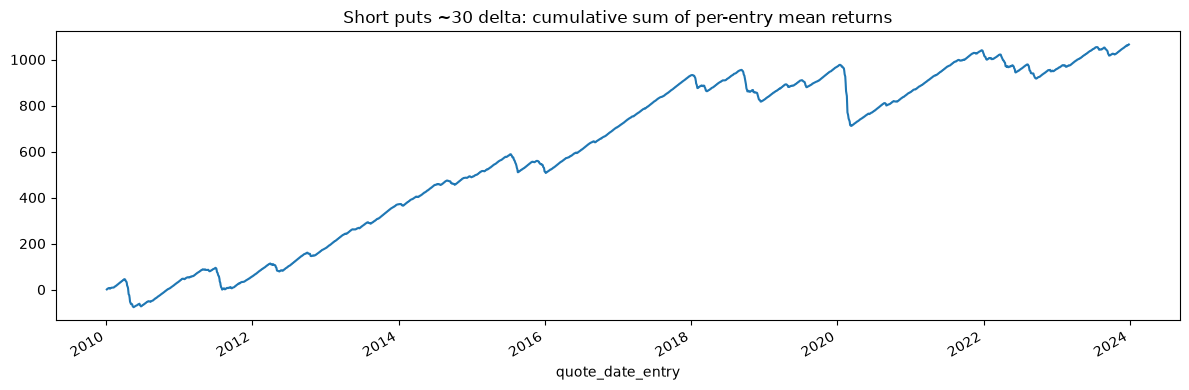

In [10]:
# Cumulative return of ~30-delta short puts, averaged per entry date
t = trades[trades["delta_entry"].abs().between(0.25, 0.35)]
(t.groupby("quote_date_entry")["pct_change"].mean().cumsum()
   .plot(figsize=(12, 4), title="Short puts ~30 delta: cumulative sum of per-entry mean returns"))
plt.tight_layout()

## 6. Next steps

- `op.simulate()` / `op.simulate_portfolio()` — capital-tracked simulation with position limits and commissions
- Other strategies: `op.short_strangles`, `op.iron_butterfly`, `op.long_put_spread`, `op.covered_call`, ... (38 total — see `dir(op)`)
- Entry signals: combine with `op.rsi_below`, `op.iv_rank_above`, `op.day_of_week`, etc. via `entry_dates=`
- Slippage: `slippage="spread"` or `"liquidity"` (liquidity mode uses the `volume` column)